# XMEAS10 · 论文结果图作图台 (operator-augmented, no gate)

生成 **Fig. 4 / 5 / 6 / 7**（论文 `paper/manuscript.docx` 的四张定量结果图）：

| Fig | 内容 | 文件 |
|-----|------|------|
| **4** | prognostic **recall** vs 数据比例 ρ（log） | `fig4_recall_vs_rho.png/pdf` |
| **5** | (a) **FAR** (b) **lead time** vs ρ（含 FAR≤0.05 预算阴影） | `fig5_far_lead_vs_rho.png/pdf` |
| **6** | **recall–FAR** 散点（每算子每 ρ 一个点）+ Pareto 前沿 + FAR=0.05 线 | `fig6_recall_far_pareto.png/pdf` |
| **7** | horizon-mean **MSE ×10³** vs ρ（log），collapsed baselines 平带 | `fig7_mse_vs_rho.png/pdf` |

**数据源**：全部数值 = `manuscript.docx` 里 Table 1(recall)/2(FAR)/3(lead)/5(MSE) 的**定稿值**逐字录入（它们本身就是 batch_metrics 的输出），因此**图与表严格一致**。
方法集与图注一致：算子池 raw/∇(diff)/∇²/Union + 两个 zero-shot(Time-MoE/Sundial) + 两个最强监督基线(STA-ConvBiLSTM/TCN-Transformer)；Fig 6 只画四个算子。
**不改** `plot_gate.ipynb`（旧 gate 作图台）。

In [1]:
# === 配置 + 数据（Table 1/2/3/5 verbatim from manuscript.docx）===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HERE = Path("/home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10")

# 数据比例 rho（论文 6 档），x 轴 log
RHO_PCT = np.array([1, 5, 10, 25, 50, 100], dtype=float)
RHO_LAB = ["1%", "5%", "10%", "25%", "50%", "100%"]

# ---- Table 1: recall ----
RECALL = {
    "union": [0.723, 0.733, 0.782, 0.782, 0.762, 0.792],
    "diff2": [0.644, 0.693, 0.713, 0.723, 0.683, 0.713],
    "diff":  [0.653, 0.604, 0.644, 0.634, 0.634, 0.673],
    "raw":   [0.446, 0.604, 0.634, 0.584, 0.644, 0.693],
    "time_moe": [0.396]*6,
    "sundial":  [0.337]*6,
    "sta":   [0.030, 0.366, 0.455, 0.455, 0.515, 0.535],
    "tcn":   [0.050, 0.188, 0.386, 0.495, 0.446, 0.446],
}
# ---- Table 2: FAR ----
FAR = {
    "diff":  [0.033, 0.033, 0.027, 0.023, 0.013, 0.017],
    "raw":   [0.011, 0.015, 0.013, 0.016, 0.021, 0.020],
    "diff2": [0.159, 0.126, 0.106, 0.084, 0.079, 0.075],
    "union": [0.163, 0.132, 0.113, 0.088, 0.081, 0.081],
    "time_moe": [0.010]*6,
    "sundial":  [0.004]*6,
    "sta":   [0.001, 0.029, 0.040, 0.012, 0.014, 0.014],
    "tcn":   [0.001, 0.008, 0.012, 0.010, 0.010, 0.030],
}
# ---- Table 3: lead time (min) ----
LEAD = {
    "union": [10.82, 10.18, 10.71, 10.61, 10.67, 10.61],
    "diff2": [10.07, 10.18, 10.29, 10.39, 9.92, 9.86],
    "diff":  [9.96, 8.79, 9.21, 9.11, 9.35, 9.78],
    "raw":   [8.09, 8.46, 8.89, 8.46, 8.89, 9.32],
    "time_moe": [7.43]*6,
    "sundial":  [7.76]*6,
    "sta":   [6.60, 8.33, 9.50, 7.44, 8.16, 8.22],
    "tcn":   [4.80, 5.50, 6.88, 7.17, 7.25, 7.80],
}
# ---- Table 5: MSE x10^3 ----
MSE = {
    "diff":  [0.087, 0.075, 0.064, 0.054, 0.051, 0.048],
    "union": [0.130, 0.102, 0.087, 0.070, 0.064, 0.058],
    "diff2": [0.159, 0.119, 0.100, 0.082, 0.071, 0.065],
    "raw":   [0.237, 0.131, 0.103, 0.093, 0.073, 0.064],
    "time_moe": [0.115]*6,
    "sundial":  [0.137]*6,
    "sta":   [0.423, 0.320, 0.263, 0.074, 0.073, 0.063],
    "tcn":   [0.405, 0.276, 0.186, 0.119, 0.129, 0.130],
}
# collapsed DL trio (MSE, flat ~0.42) -> Fig 7 band
MSE_COLLAPSED = {
    "DiPCA-LSTM": [0.424, 0.424, 0.425, 0.426, 0.429, 0.427],
    "CNN-LSTM":   [0.423, 0.423, 0.423, 0.423, 0.424, 0.424],
    "LSTM-GRU":   [0.424, 0.423, 0.424, 0.424, 0.424, 0.425],
}

# ---- 配色（沿用 plot_gate.ipynb 房子色）----
IKB="#002FA7"; INK="#0a0a0a"; GREY_DARK="#5c5c5c"; GREY_MID="#8f8f8d"
GREY_LIGHT="#c4c4c2"; PAPER="#ffffff"
STYLE = {   # key -> (color, marker, linestyle, lw, label)
    "raw":   ("#0f8f66", "s", "-",            2.0, "Timer-XL raw"),
    "diff":  ("#eb6834", "o", "-",            2.0, r"Timer-XL $\nabla$ (diff)"),
    "diff2": ("#8338ec", "^", "-",            2.0, r"Timer-XL $\nabla^{2}$"),
    "union": (IKB,       "*", "-",            2.6, r"Union ($\nabla,\ \nabla^{2}$)"),
    "time_moe": ("#4a3aa7", None, (0,(5,2.5)),1.7, "Time-MoE (zero-shot)"),
    "sundial":  ("#e34948", None, (0,(5,2.5)),1.7, "Sundial (zero-shot)"),
    "sta":   ("#3c7f8f", "x", (0,(1,1.4)),    1.6, "STA-ConvBiLSTM"),
    "tcn":   ("#c25b4e", "+", (0,(1,1.4)),    1.6, "TCN-Transformer"),
}
OPS      = ["raw", "diff", "diff2", "union"]     # 算子池
ZEROSHOT = ["time_moe", "sundial"]
BASE2    = ["sta", "tcn"]                          # 两个最强监督基线
FIG4SET  = OPS + ZEROSHOT + BASE2                  # Fig 4/5/7 方法集

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "axes.linewidth": 0.8, "svg.fonttype": "none",
})

def _base_ax(ax):
    ax.set_facecolor(PAPER)
    ax.grid(color=GREY_LIGHT, lw=0.6, alpha=0.55, zorder=0)
    for s in ax.spines.values(): s.set_color(GREY_LIGHT)
    ax.tick_params(colors=GREY_DARK, labelsize=9)

def _plot_curve(ax, key, ydict, big_marker=False):
    c, mk, ls, lw, lab = STYLE[key]
    y = ydict[key]
    is_op = key in OPS
    ax.plot(RHO_PCT, y, color=c, ls=ls, lw=lw, marker=mk,
            ms=(9 if key=="union" else 5.5) if is_op else 5.0,
            mfc=(c if key=="union" else PAPER) if is_op else c,
            mec=c, mew=1.4 if is_op else 1.0,
            zorder=(9 if key=="union" else 6) if is_op else 4,
            label=lab, clip_on=True)

def _finish_x(ax):
    ax.set_xscale("log")
    ax.set_xticks(RHO_PCT); ax.set_xticklabels(RHO_LAB)
    ax.set_xlim(0.85, 118)
    ax.set_xlabel(r"training-subset ratio  $\rho$   (log scale)", fontsize=10.5, color=GREY_DARK)

def _save(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(HERE / f"{stem}.{ext}", dpi=300, facecolor=PAPER, bbox_inches="tight")
    print("saved:", HERE / f"{stem}.png", "+ .pdf")

print("cell1 ok · methods:", FIG4SET)


cell1 ok · methods: ['raw', 'diff', 'diff2', 'union', 'time_moe', 'sundial', 'sta', 'tcn']


## Fig. 3 — 两个示例窗口（从 H=5 算子预测数组，非表格）

held-out 测试集上两个 ante-onset 窗口，展示 (ℓ, u) 带、真值、以及 ∇/∇²/Union 预测：
- **(a) gi 3566**（Run10, 92.65 h）：稳定爬坡，**∇(diff) 贴合真值并越过 u → 抓到**。
- **(b) gi 535**（Run9, 31.55 h）：曲线加速上冲，**∇ 平在带内漏掉；∇² 加速穿过 u → 抓到**。

**Union 用方向感知包络表示**（up-onset = max(∇,∇²)，down = min），阴影带 = [min,max]，蓝星 = union 首次越限点。
数据源 = `results/forecast_...diff_train25p5...`（∇）与 `results/op_diff2_p5_test`（∇²），mag25 限 `setting/limits_tep_xmeas10_mag25.csv`。

saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/testset_purge_rate.png + .pdf


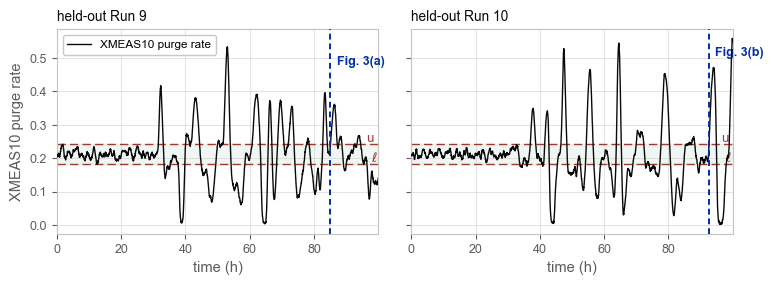

In [2]:
# --- Fig. 3 example windows :: SINGLE SOURCE OF TRUTH (global window indices gi) ---
# Both the test-set overview cell and Fig. 3 read from here -> they can never drift.
# (a)=steady-ramp onset (grad & grad2 catch, all baselines miss); (b)=curving onset (only grad2).
FIG3_WIN = {"a": 1604, "b": 3563}

# === Test-set overview — XMEAS10 purge rate on the held-out runs (Run 9, Run 10, mag25) ===
# Full measured trajectories that Fig. 3's example windows are drawn from. Same (ell, u)
# band as Fig. 3; each dashed IKB line marks an example window's forecast origin (t=0),
# computed from the SAME global window index gi as Fig. 3's PANELS -> exact correspondence.
import pandas as pd
_LOW = Path("/home/aicode/sherwin/dataset/TEP/csv_5var_lowmag")
_TGT = "XMEAS10 Purge Rate"; _STEP_MIN = 3.0; _SEQ = 96
def _series(run):
    return pd.read_csv(sorted(_LOW.glob(f"*IDV13*_25_Run{run}.csv"))[0])[_TGT].to_numpy(float)
_lim = pd.read_csv(Path("/home/aicode/sherwin/TSFM/setting/limits_tep_xmeas10_mag25.csv"), index_col=0)
_ELL, _U = float(_lim.loc[_TGT].iloc[2]), float(_lim.loc[_TGT].iloc[1])

# --- Fig. 3 example windows: keep these global indices identical to Fig. 3's PANELS ---
_GI = list(FIG3_WIN.items())          # single source of truth (cell 1)
_WPR = len(_series(9)) - _SEQ - _SEQ + 1                      # windows per run
def _origin(gi):                                             # -> (run, origin sample index)
    run, local = (9, gi) if gi < _WPR else (10, gi - _WPR)
    return run, _SEQ + local - 1                             # t=0 = ctx[-1] = s[st-1], as in Fig. 3
_MARKS = {}
for tag, gi in _GI:
    r, so = _origin(gi); _MARKS.setdefault(r, []).append((so, tag))

fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 7.5/2.54), sharey=True)
fig.patch.set_facecolor(PAPER)
for ax, run in zip(axes, (9, 10)):
    _base_ax(ax)
    s = _series(run); t = np.arange(len(s)) * _STEP_MIN / 60.0            # hours
    ax.axhspan(_ELL, _U, color="#2e8b57", alpha=0.07, zorder=0)
    for yv, nm in ((_U, "u"), (_ELL, r"$\ell$")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), zorder=2)
        ax.text(t[-1], yv, f"{nm} ", color="#a03a2e", fontsize=9.5, va="bottom", ha="right")
    ax.plot(t, s, color=INK, lw=1.0, zorder=4,
            label=("XMEAS10 purge rate" if run == 9 else None))
    for so, tag in _MARKS.get(run, []):
        to = t[so]
        ax.axvline(to, color=IKB, lw=1.4, ls=(0, (3, 2)), zorder=5)
        ax.annotate(f"Fig. 3({tag})", (to, ax.get_ylim()[1]), textcoords="offset points",
                    xytext=(5, -13), fontsize=9, color=IKB, fontweight="bold", va="top")
    ax.set_xlabel("time (h)", fontsize=10.5, color=GREY_DARK)
    ax.set_title(f"held-out Run {run}", fontsize=9.8, color=INK, loc="left", pad=6)
    ax.set_xlim(t[0], t[-1])
axes[0].set_ylabel("XMEAS10 purge rate", fontsize=10.5, color=GREY_DARK)
axes[0].legend(fontsize=8.5, loc="upper left", framealpha=0.92, edgecolor=GREY_LIGHT)
fig.tight_layout(); _save(fig, "testset_purge_rate"); plt.show()

saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig3_examples.png + .pdf


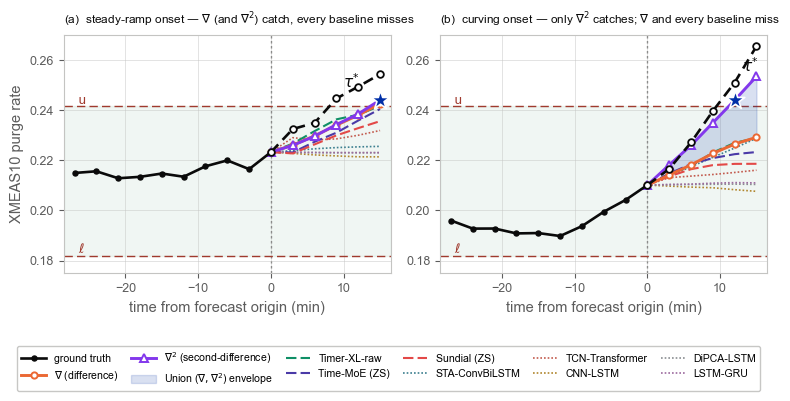

In [3]:
# === Fig. 3 — two example ante-onset windows: operators vs ALL baselines (H=5, r1p0) ===
# Data dirs = 100%-data (r1p0) block of setting/bm_fullsweep.yaml; mag25 limits, eval_steps=5.
# DL baselines are the diff-input, mag25-trained (train25) variants (the paper set), restored
# to the raw purge-rate domain (pred.npy). All method arrays share the 3618-window test order.
import pandas as pd
RES        = Path("/home/aicode/sherwin/TSFM/results")
LOWMAG_DIR = Path("/home/aicode/sherwin/dataset/TEP/csv_5var_lowmag")
TSFM_ROOT  = Path("/home/aicode/sherwin/TSFM")
SEQ_LEN = PRED_LEN = 96; H5 = 5; TGT = "XMEAS10 Purge Rate"
_BSUF = "timer_xl_MultivariateDatasetYAMLSplitFewShot_sl96_it96_ot96_lr5e-06_bt32_wd0_el8_dm1024_dff2048_nh8_cosTrue_test_0"
def _dl(m, dm, dff, el):
    return (f"long_term_forecast_TEP_IDV13_XMEAS10_5var_diff_{m}_train25_r1p0_{m}"
            f"_MultivariateDatasetYAMLSplitFewShot_sl96_it96_ot96_lr0.001_bt128_wd0"
            f"_el{el}_dm{dm}_dff{dff}_nh8_cosTrue_{m}-X10-diff_0")
DIRS = {
    "diff":  f"forecast_TEP_IDV13_XMEAS10_5var_diff_train25p5_few_r1p0_{_BSUF}",
    "diff2": "op_diff2_p5_test",
    "raw":   f"forecast_TEP_IDV13_XMEAS10_5var_raw_train25p5_few_r1p0_{_BSUF}",
    "time_moe": "fm_time_moe_xmeas10_mag25_test",
    "sundial":  "fm_sundial_xmeas10_mag25_test",
    "cnnlstm":  _dl("CNNLSTM", 230, 1408, 2),
    "dipca":    _dl("DiPCALSTM", 472, 2048, 2),
    "lstmgru":  _dl("LSTMGRU", 316, 2048, 1),
    "sta":      _dl("STAConvBiLSTM", 268, 2048, 1),
    "tcn":      _dl("TCNTransformer", 128, 512, 2),
}
def _csv(run):
    return pd.read_csv(sorted(LOWMAG_DIR.glob(f"*IDV13*_25_Run{run}.csv"))[0])[TGT].to_numpy(float)
def _limits():
    df = pd.read_csv(TSFM_ROOT / "setting/limits_tep_xmeas10_mag25.csv", index_col=0)
    return float(df.loc[TGT].iloc[2]), float(df.loc[TGT].iloc[1])           # (ell, u)
def _p5(d):
    p = np.load(RES / d / "pred.npy"); return (p[:, :, 0] if p.ndim == 3 else p)[:, :H5].astype(float)

ELL, U = _limits()
F = {k: _p5(v) for k, v in DIRS.items()}
WPR = len(_csv(9)) - SEQ_LEN - PRED_LEN + 1
_loc = lambda gi: (9, gi) if gi < WPR else (10, gi - WPR)

# ---- visual tiers -------------------------------------------------------
C_D, C_D2 = STYLE["diff"][0], STYLE["diff2"][0]
TSFM_STY = {   # foundation-model baselines: dashed, coloured, thin
    "raw":      ("Timer-XL-raw",  STYLE["raw"][0],      (0, (5, 2)), 1.5),
    "time_moe": ("Time-MoE (ZS)", STYLE["time_moe"][0], (0, (5, 2)), 1.5),
    "sundial":  ("Sundial (ZS)",  STYLE["sundial"][0],  (0, (5, 2)), 1.5),
}
DL_STY = {     # supervised DL baselines: dotted, muted, thinner
    "sta":     ("STA-ConvBiLSTM",  "#3c7f8f", (0, (1, 1.2)), 1.2),
    "tcn":     ("TCN-Transformer", "#c25b4e", (0, (1, 1.2)), 1.2),
    "cnnlstm": ("CNN-LSTM",        "#b0862e", (0, (1, 1.2)), 1.2),
    "dipca":   ("DiPCA-LSTM",      "#8a8d91", (0, (1, 1.2)), 1.2),
    "lstmgru": ("LSTM-GRU",        "#9c6a9e", (0, (1, 1.2)), 1.2),
}
PANELS = [("a", FIG3_WIN["a"], r"steady-ramp onset — $\nabla$ (and $\nabla^{2}$) catch, every baseline misses"),
          ("b", FIG3_WIN["b"], r"curving onset — only $\nabla^{2}$ catches; $\nabla$ and every baseline miss")]
CTX = 10
fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 10/2.54)); fig.patch.set_facecolor(PAPER)
H = {}   # label -> handle (for one shared legend)
for ax, (tag, gi, note) in zip(axes, PANELS):
    _base_ax(ax)
    run, local = _loc(gi); s = _csv(run); st = SEQ_LEN + local
    ctx = s[st-CTX:st]; fut = s[st:st+H5]
    tctx = (np.arange(-CTX, 0) + 1) * 3.0; tf = np.arange(1, H5+1) * 3.0
    x = np.r_[0, tf]
    diff, dff2 = F["diff"][gi], F["diff2"][gi]
    up = (fut > U).any()
    edge = np.maximum(diff, dff2) if up else np.minimum(diff, dff2)          # union active edge
    # (ell,u) band
    ax.axhspan(ELL, U, color="#2e8b57", alpha=0.07, zorder=0)
    for yv, nm in ((U, "u"), (ELL, r"$\ell$")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), zorder=2)
        ax.text(tctx[0], yv, f" {nm}", color="#a03a2e", fontsize=9.5, va="bottom", ha="left")
    ax.axvline(0, color=GREY_DARK, lw=0.9, ls=(0, (2, 2)), zorder=1)
    # DL baselines (bottom tier)
    for k, (lbl, col, ls, lw) in DL_STY.items():
        h, = ax.plot(x, np.r_[ctx[-1], F[k][gi]], color=col, ls=ls, lw=lw, zorder=3)
        H.setdefault(lbl, h)
    # TSFM baselines (mid tier)
    for k, (lbl, col, ls, lw) in TSFM_STY.items():
        h, = ax.plot(x, np.r_[ctx[-1], F[k][gi]], color=col, ls=ls, lw=lw, zorder=4)
        H.setdefault(lbl, h)
    # Union envelope (operator)
    hU = ax.fill_between(tf, np.minimum(diff, dff2), np.maximum(diff, dff2),
                         color=IKB, alpha=0.15, zorder=2)
    H.setdefault(r"Union ($\nabla,\nabla^{2}$) envelope", hU)
    # operators (hero)
    hd, = ax.plot(x, np.r_[ctx[-1], diff], color=C_D, lw=2.1, marker="o", ms=4.5,
                  mfc=PAPER, mew=1.4, zorder=6); H.setdefault(r"$\nabla$ (difference)", hd)
    h2, = ax.plot(x, np.r_[ctx[-1], dff2], color=C_D2, lw=2.1, marker="^", ms=5.6,
                  mfc=PAPER, mew=1.4, zorder=6); H.setdefault(r"$\nabla^{2}$ (second-difference)", h2)
    # ground truth (top)
    hg, = ax.plot(tctx, ctx, color=INK, lw=1.9, marker="o", ms=3.6, zorder=7)
    ax.plot(x, np.r_[ctx[-1], fut], color=INK, lw=1.9, ls=(0, (4, 2.4)),
            marker="o", ms=4.8, mfc=PAPER, mew=1.3, zorder=7)
    H.setdefault("ground truth", hg)
    # union first crossing star
    cu = np.where((edge > U) | (edge < ELL))[0]
    if len(cu):
        ax.scatter(tf[cu[0]], edge[cu[0]], s=200, marker="*", c=IKB,
                   edgecolor="white", linewidth=1.2, zorder=9)
    # true first crossing tau*
    ctr = np.where((fut > U) | (fut < ELL))[0]
    if len(ctr):
        ax.annotate(r"$\tau^{*}$", (tf[ctr[0]], fut[ctr[0]]), textcoords="offset points",
                    xytext=(5, 8), fontsize=11, color=INK)
    allv = np.concatenate([ctx, fut] + [F[k][gi] for k in DIRS])
    ax.set_ylim(0.175, 0.27)
    # ax.set_ylim(min(ELL, allv.min()) - 0.004, max(U, allv.max()) + 0.007)
    ax.set_xlim(tctx[0] - 1.5, tf[-1] + 1.5)
    ax.set_xlabel("time from forecast origin (min)", fontsize=10.5, color=GREY_DARK)
    ax.set_title(f"({tag})  {note}", fontsize=8.6, color=INK, loc="left", pad=8)
axes[0].set_ylabel("XMEAS10 purge rate", fontsize=10.5, color=GREY_DARK)
order = ["ground truth", r"$\nabla$ (difference)", r"$\nabla^{2}$ (second-difference)",
         r"Union ($\nabla,\nabla^{2}$) envelope",
         "Timer-XL-raw", "Time-MoE (ZS)", "Sundial (ZS)",
         "STA-ConvBiLSTM", "TCN-Transformer", "CNN-LSTM", "DiPCA-LSTM", "LSTM-GRU"]
fig.legend([H[k] for k in order], order, loc="lower center", ncol=6, fontsize=7.6,
           framealpha=0.95, edgecolor=GREY_LIGHT, columnspacing=1.2, handlelength=2.3,
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.15, 1, 1))
_save(fig, "fig3_examples"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig4_recall_vs_rho.png + .pdf


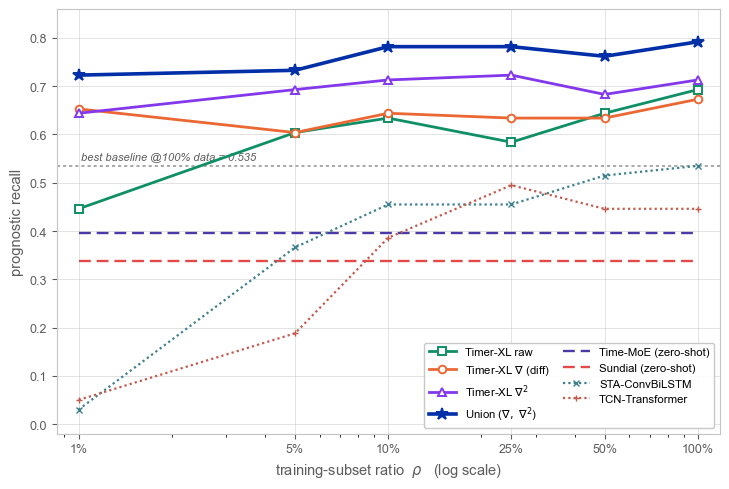

In [4]:
# === Fig. 4 — prognostic recall vs rho ===
fig, ax = plt.subplots(figsize=(7.4, 5.0)); fig.patch.set_facecolor(PAPER)
_base_ax(ax)
# best-baseline @100% reference (headline: operators @1% already beat it)
best_base_100 = max(RECALL["sta"][-1], RECALL["tcn"][-1])   # 0.535 (STA)
ax.axhline(best_base_100, color=GREY_MID, ls=(0,(2,2)), lw=1.1, zorder=1)
ax.text(1.02, best_base_100+0.008, f"best baseline @100% data = {best_base_100:.3f}",
        fontsize=8.0, color=GREY_DARK, va="bottom", ha="left", style="italic")
for k in FIG4SET:
    _plot_curve(ax, k, RECALL)
_finish_x(ax)
ax.set_ylabel("prognostic recall", fontsize=10.5, color=GREY_DARK)
ax.set_ylim(-0.02, 0.86)
ax.legend(fontsize=8.2, ncol=2, loc="lower right", framealpha=0.92,
          edgecolor=GREY_LIGHT, columnspacing=1.1, handlelength=2.4)
fig.tight_layout(); _save(fig, "fig4_recall_vs_rho"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig5_far_lead_vs_rho.png + .pdf


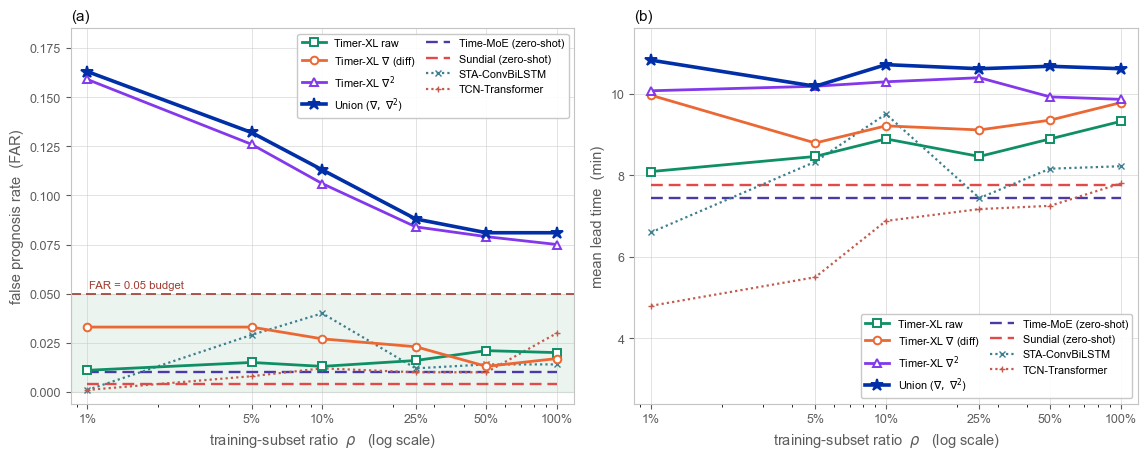

In [5]:
# === Fig. 5 — (a) FAR  (b) lead time vs rho ===
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11.6, 4.7)); fig.patch.set_facecolor(PAPER)
for ax in (axa, axb): _base_ax(ax)

# (a) FAR  — shade FAR<=0.05 budget
axa.axhspan(0, 0.05, color="#2e8b57", alpha=0.09, zorder=0)
axa.axhline(0.05, color="#a03a2e", lw=1.2, ls=(0,(6,3)), zorder=2)
axa.text(1.02, 0.052, "FAR = 0.05 budget", fontsize=8.2, color="#a03a2e", va="bottom", ha="left")
for k in FIG4SET: _plot_curve(axa, k, FAR)
_finish_x(axa)
axa.set_ylabel("false prognosis rate  (FAR)", fontsize=10.5, color=GREY_DARK)
axa.set_ylim(-0.006, 0.185)
axa.set_title("(a)", fontsize=11, color=INK, loc="left", pad=6)
axa.legend(fontsize=7.8, ncol=2, loc="upper right", framealpha=0.92,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)

# (b) lead time
for k in FIG4SET: _plot_curve(axb, k, LEAD)
_finish_x(axb)
axb.set_ylabel("mean lead time  (min)", fontsize=10.5, color=GREY_DARK)
axb.set_ylim(2.4, 11.6)
axb.set_title("(b)", fontsize=11, color=INK, loc="left", pad=6)
axb.legend(fontsize=7.8, ncol=2, loc="lower right", framealpha=0.92,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)
fig.tight_layout(); _save(fig, "fig5_far_lead_vs_rho"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig6_recall_far_pareto.png + .pdf


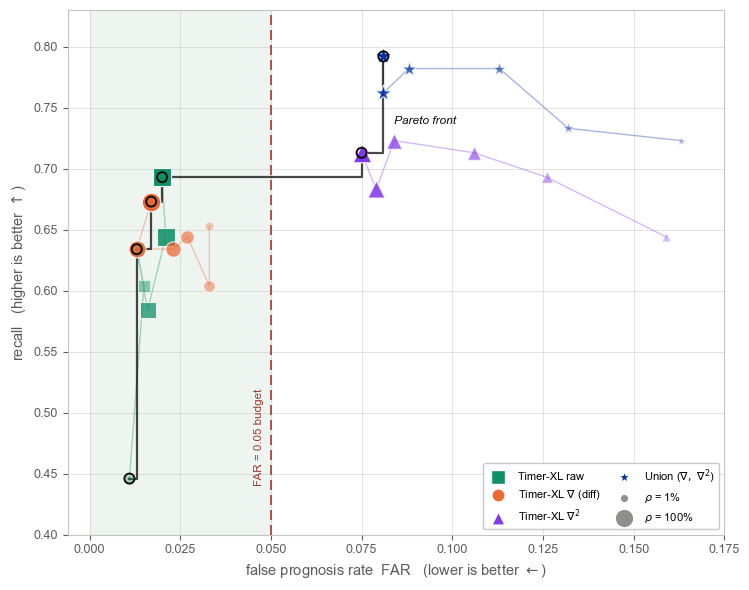

In [6]:
# === Fig. 6 — recall vs FAR, one marker per (operator, rho) + Pareto front ===
fig, ax = plt.subplots(figsize=(7.6, 6.0)); fig.patch.set_facecolor(PAPER)
_base_ax(ax)
# FAR=0.05 budget
ax.axvspan(0, 0.05, color="#2e8b57", alpha=0.08, zorder=0)
ax.axvline(0.05, color="#a03a2e", lw=1.2, ls=(0,(6,3)), zorder=2)
ax.text(0.048, 0.44, "FAR = 0.05 budget", color="#a03a2e", fontsize=8.4,
        rotation=90, va="bottom", ha="right")

pts = []   # (far, recall, op, rho_idx)
sizes = np.linspace(38, 180, len(RHO_PCT))     # small rho -> small marker
for op in OPS:
    c, mk, ls, lw, lab = STYLE[op]
    fx = FAR[op]; ry = RECALL[op]
    # faint trajectory across rho
    ax.plot(fx, ry, color=c, lw=1.0, alpha=0.35, zorder=3)
    for i in range(len(RHO_PCT)):
        ax.scatter(fx[i], ry[i], s=sizes[i], marker=mk, c=c, alpha=0.35+0.65*i/5,
                   edgecolor="white", linewidth=0.8, zorder=6)
        pts.append((fx[i], ry[i], op, i))
    ax.scatter([], [], s=90, marker=mk, c=c, edgecolor="white", label=lab)  # legend proxy

# empirical Pareto front (max recall, min FAR)
P = sorted(pts, key=lambda p: (p[0], -p[1]))
front, best = [], -1
for far, rec, op, i in P:
    if rec > best:
        front.append((far, rec)); best = rec
fx = [p[0] for p in front]; fy = [p[1] for p in front]
# step line (up-left frontier)
sx, sy = [], []
for j in range(len(front)):
    sx.append(fx[j]); sy.append(fy[j])
    if j+1 < len(front): sx.append(fx[j+1]); sy.append(fy[j])
ax.plot(sx, sy, color=INK, lw=1.6, ls="-", zorder=5, alpha=0.75)
ax.scatter(fx, fy, s=52, facecolor="none", edgecolor=INK, linewidth=1.4, zorder=8)
ax.text(0.084, 0.735, "Pareto front", fontsize=8.6, color=INK, style="italic",
        rotation=0, va="bottom", ha="left")

# rho size legend
for i in (0, 5):
    ax.scatter([], [], s=sizes[i], marker="o", c=GREY_MID, edgecolor="white",
               label=f"$\\rho$ = {RHO_LAB[i]}")
ax.set_xlabel(r"false prognosis rate  FAR   (lower is better $\leftarrow$)",
              fontsize=10.5, color=GREY_DARK)
ax.set_ylabel(r"recall   (higher is better $\uparrow$)", fontsize=10.5, color=GREY_DARK)
ax.set_xlim(-0.006, 0.175); ax.set_ylim(0.40, 0.83)
ax.legend(fontsize=8.0, loc="lower right", framealpha=0.92, edgecolor=GREY_LIGHT,
          ncol=2, columnspacing=1.0)
fig.tight_layout(); _save(fig, "fig6_recall_far_pareto"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig7_mse_vs_rho.png + .pdf


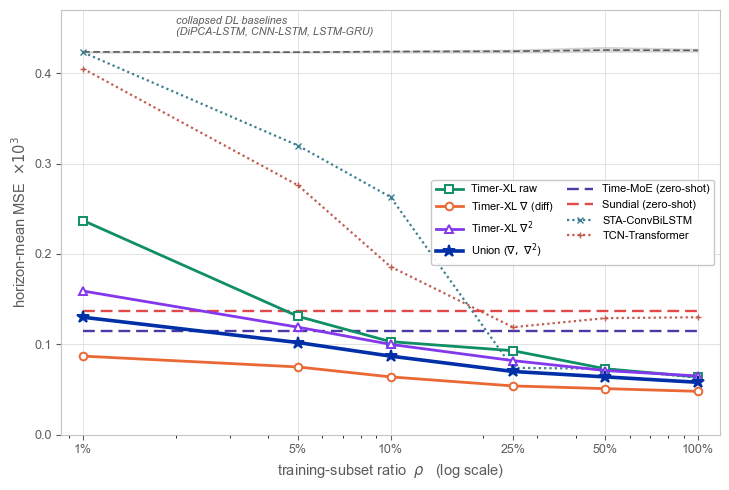

In [7]:
# === Fig. 7 — horizon-mean MSE x10^3 vs rho ===
fig, ax = plt.subplots(figsize=(7.4, 5.0)); fig.patch.set_facecolor(PAPER)
_base_ax(ax)
# collapsed DL baselines -> grey band near 0.42
allc = np.array(list(MSE_COLLAPSED.values()))
lo, hi = allc.min(0), allc.max(0)
ax.fill_between(RHO_PCT, lo, hi, color=GREY_MID, alpha=0.28, zorder=1)
ax.plot(RHO_PCT, allc.mean(0), color=GREY_DARK, lw=1.2, ls=(0,(4,2)), zorder=2)
ax.text(2.0, 0.44, "collapsed DL baselines\n(DiPCA-LSTM, CNN-LSTM, LSTM-GRU)",
        fontsize=7.8, color=GREY_DARK, va="bottom", ha="left", style="italic")
for k in FIG4SET: _plot_curve(ax, k, MSE)
_finish_x(ax)
ax.set_ylabel(r"horizon-mean MSE  $\times 10^{3}$", fontsize=10.5, color=GREY_DARK)
ax.set_ylim(0.0, 0.47)
ax.legend(fontsize=8.0, ncol=2, loc="center right", framealpha=0.92,
          edgecolor=GREY_LIGHT, columnspacing=1.1, handlelength=2.4)
fig.tight_layout(); _save(fig, "fig7_mse_vs_rho"); plt.show()
